In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import glob

In [7]:
root = r"C:\Users\oxcy\Desktop\EMTEQ PROEKT\FEIT_eating_S05"
subjects = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]

In [8]:
subjects

['Andrej Petrov',
 'Angela Nastovska',
 'Bojan Dimovski',
 'Bojan Radovski',
 'Damjan Srebrenkoski',
 'Daniela Kovachovska',
 'Filip Sivevski',
 'Gorica Kovachovska',
 'Ilina Kovachovska',
 'Iva Jovanova',
 'Ivana Kiprijanovska',
 'Jovana Kostadinovska',
 'Kristijan Milosheski',
 'Marija Kovachovska',
 'Marko Kostov',
 'Matej Zlatkov',
 'Monika Stoilkovska',
 'Nikola Dimovski',
 'Ognen Sekuloski',
 'Sandra Shandarovska',
 'Sara Ilievska',
 'Sara Kovachovska',
 'Sashko Kovachovski',
 'Stefan Dinushev',
 'Stefanija Lazarovska',
 'Tarek Abd El-Azis',
 'Teodora Domazetovikj',
 'Tomi Jovanov',
 'Tomi Nikoloski',
 'Vasko Dimitrovski',
 'Vedrana Petreska',
 'Vladimir Petrov']

In [9]:
len(subjects)

32

In [10]:
subject_csv = {}

for s in subjects:
    subj_dir = os.path.join(root, s)
    csvs = glob.glob(os.path.join(subj_dir, "eating_processed.csv"))

    if len(csvs) == 0:
        print(f" NO eating_processed for {s}")
    elif len(csvs) > 1:
        print(f" MORE than one for {s}, using first")
        subject_csv[s] = csvs[0]
    else:
        subject_csv[s] = csvs[0]

print("Total subjects with eating_processed:", len(subject_csv))

Total subjects with eating_processed: 32


In [11]:
def load_subject_df(subject):
    csv_path = subject_csv[subject]
    df = pd.read_csv(csv_path)
    df["subject"] = subject
    return df

In [14]:
#fiksirani – subject-level split

train_subjects = [
    "Teodora Domazetovikj",
    "Daniela Kovachovska",
    "Ivana Kiprijanovska",
    "Matej Zlatkov",
    "Tarek Abd El-Azis",
    "Jovana Kostadinovska",
    "Sashko Kovachovski",
    "Filip Sivevski",
    "Sandra Shandarovska",
    "Kristijan Milosheski",
    "Monika Stoilkovska",
    "Iva Jovanova",
    "Tomi Nikoloski",
    "Marko Kostov",
    "Stefanija Lazarovska",
    "Sara Ilievska",
    "Vedrana Petreska",
    "Angela Nastovska",
    "Marija Kovachovska",
    "Ognen Sekuloski",
    "Bojan Dimovski",
    "Nikola Dimovski"
]

val_subjects = [
    "Sara Kovachovska",
    "Bojan Radovski",
    "Vasko Dimitrovski",
    "Damjan Srebrenkoski",
    "Tomi Jovanov"
]

test_subjects = [
    "Vladimir Petrov",
    "Ilina Kovachovska",
    "Stefan Dinushev",
    "Andrej Petrov",
    "Gorica Kovachovska"
]

print("TRAIN:", len(train_subjects), train_subjects)
print("VAL:",   len(val_subjects), val_subjects)
print("TEST:",  len(test_subjects), test_subjects)

TRAIN: 22 ['Teodora Domazetovikj', 'Daniela Kovachovska', 'Ivana Kiprijanovska', 'Matej Zlatkov', 'Tarek Abd El-Azis', 'Jovana Kostadinovska', 'Sashko Kovachovski', 'Filip Sivevski', 'Sandra Shandarovska', 'Kristijan Milosheski', 'Monika Stoilkovska', 'Iva Jovanova', 'Tomi Nikoloski', 'Marko Kostov', 'Stefanija Lazarovska', 'Sara Ilievska', 'Vedrana Petreska', 'Angela Nastovska', 'Marija Kovachovska', 'Ognen Sekuloski', 'Bojan Dimovski', 'Nikola Dimovski']
VAL: 5 ['Sara Kovachovska', 'Bojan Radovski', 'Vasko Dimitrovski', 'Damjan Srebrenkoski', 'Tomi Jovanov']
TEST: 5 ['Vladimir Petrov', 'Ilina Kovachovska', 'Stefan Dinushev', 'Andrej Petrov', 'Gorica Kovachovska']


In [15]:
train_dfs = [load_subject_df(s) for s in train_subjects if s in subject_csv]
val_dfs   = [load_subject_df(s) for s in val_subjects   if s in subject_csv]
test_dfs  = [load_subject_df(s) for s in test_subjects  if s in subject_csv]

print(len(train_dfs), len(val_dfs), len(test_dfs))

22 5 5


In [16]:
cols_to_drop = [
    "SoftwareTimestamp",
    "Timestamp",
    "Accelerometer/Raw.Z",
    "Gyroscope/Raw.Z",
    "Magnetometer/Raw.X",
    "Magnetometer/Raw.Y",
    "Magnetometer/Raw.Z",
    "Nav/Shutter[LeftTemple]",
    "Nav/FrameAvg[LeftTemple]",
    "Pressure/Raw", 
    "RotationVector/Raw.W",
    "RotationVector/Raw.Z",
]

train_dfs = [df.drop(columns=cols_to_drop, errors="ignore") for df in train_dfs]
val_dfs   = [df.drop(columns=cols_to_drop, errors="ignore") for df in val_dfs]
test_dfs  = [df.drop(columns=cols_to_drop, errors="ignore") for df in test_dfs]

In [17]:
train_df = pd.concat(train_dfs, ignore_index=True)
val_df   = pd.concat(val_dfs,   ignore_index=True)
test_df  = pd.concat(test_dfs,  ignore_index=True)

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["subject"].nunique(),
      val_df["subject"].nunique(),
      test_df["subject"].nunique())

(705651, 12) (153829, 12) (136385, 12)
22 5 5


In [ ]:
def make_windows_from_dfs(
    dfs,
    label_col,
    feature_cols=None,
    window_samples=150,
    step_samples=25,
    label_strategy="majority"
):
    X_list, y_list = [], []

    for df in dfs:
        
        if feature_cols is None:
            num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            feature_cols = [c for c in num_cols if c != label_col]

        X_raw = df[feature_cols].to_numpy(dtype=np.float32)
        y_raw = df[label_col].to_numpy()

        n = len(X_raw)
        if n < window_samples:
            continue

        for start in range(0, n - window_samples + 1, step_samples):
            end = start + window_samples
            Xw = X_raw[start:end]

            y_seg = y_raw[start:end]
            if label_strategy == "last":
                yw = y_seg[-1]
            else:
                vals, counts = np.unique(y_seg, return_counts=True)
                yw = vals[np.argmax(counts)]

            X_list.append(Xw)
            y_list.append(yw)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list)
    return X, y

In [ ]:
label_col   = "Annotations"
subject_col = "subject"
time_col    = "SoftwareTimestamp"  

exclude = {label_col, subject_col, "SoftwareTimestamp", "Timestamp"}
feature_cols = [c for c in train_df.columns if c not in exclude]

print("n_features =", len(feature_cols))
print("first features:", feature_cols[:10])


n_features = 10
first features: ['Accelerometer/Raw.X', 'Accelerometer/Raw.Y', 'Gyroscope/Raw.X', 'Gyroscope/Raw.Y', 'RotationVector/Raw.X', 'RotationVector/Raw.Y', 'Nav/Raw.X[LeftTemple]', 'Nav/Raw.Y[LeftTemple]', 'Prox/Raw[LeftTemple]', 'Nav/IQ[LeftTemple]']


In [20]:
LABEL_COL = "Annotations"
WINDOW_SEC = 4.0
STEP_SEC   = 0.5

WINDOW_SAMPLES = int(round(WINDOW_SEC * 50))
STEP_SAMPLES   = int(round(STEP_SEC * 50))

print("Window samples:", WINDOW_SAMPLES, "| Step samples:", STEP_SAMPLES)

Window samples: 200 | Step samples: 25


In [21]:
X_train, y_train = make_windows_from_dfs(train_dfs, label_col=LABEL_COL,feature_cols=feature_cols,
                                        window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES)
X_val, y_val     = make_windows_from_dfs(val_dfs,   label_col=LABEL_COL,feature_cols=feature_cols,
                                        window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES)
X_test, y_test   = make_windows_from_dfs(test_dfs,  label_col=LABEL_COL,feature_cols=feature_cols,
                                        window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES)

print(X_train.shape, X_val.shape, X_test.shape)
print("labels:", np.unique(y_train))

(28061, 200, 10) (6116, 200, 10) (5419, 200, 10)
labels: [0 1]


In [22]:
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (28061, 200, 10) (28061,)
Val:   (6116, 200, 10) (6116,)
Test:  (5419, 200, 10) (5419,)


In [23]:
mean = X_train.mean(axis=(0,1), keepdims=True)
std  = X_train.std(axis=(0,1), keepdims=True)
std[std == 0] = 1

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

print("train mean first 5 feats:", X_train.mean(axis=(0,1))[:5])
print("train std  first 5 feats:", X_train.std(axis=(0,1))[:5])

train mean first 5 feats: [ 4.6527488e-04 -2.2359291e-01  5.7935631e-07 -2.2583384e-07
 -5.6996085e-03]
train std  first 5 feats: [1.0002505  0.9735126  0.99983466 0.9992957  0.99972796]


In [24]:
print(train_df.columns.tolist())


['Accelerometer/Raw.X', 'Accelerometer/Raw.Y', 'Gyroscope/Raw.X', 'Gyroscope/Raw.Y', 'RotationVector/Raw.X', 'RotationVector/Raw.Y', 'Nav/Raw.X[LeftTemple]', 'Nav/Raw.Y[LeftTemple]', 'Prox/Raw[LeftTemple]', 'Nav/IQ[LeftTemple]', 'Annotations', 'subject']


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix, classification_report

In [26]:
input_shape = (X_train.shape[1], X_train.shape[2])  # (200, 12)

model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv1D(64, 7, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling1D(2),
    layers.Dropout(0.2),

    layers.Conv1D(128, 5, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling1D(2),
    layers.Dropout(0.2),

    layers.Conv1D(256, 3, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 64)        │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,497 (634.75 KB)

 Trainable params: 161,601 (631.25 KB)

 Non-trainable params: 896 (3.50 KB)

In [27]:
from sklearn.utils.class_weight import compute_class_weight

In [28]:
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
class_weight # dali klasite se ramnomerni

{0: 1.3180366369187413, 1: 0.8056097841065687}

In [29]:
cb = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                     patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                         factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=256,
    #class_weight=class_weight,  # ako sakash go dodavame tuka
    callbacks=cb,
    verbose=1
)

Epoch 1/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8341 - auc: 0.9015 - loss: 0.3807 - precision: 0.8508 - recall: 0.8887 - val_accuracy: 0.8921 - val_auc: 0.9427 - val_loss: 0.3039 - val_precision: 0.9291 - val_recall: 0.9161 - learning_rate: 0.0010
Epoch 2/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.8697 - auc: 0.9364 - loss: 0.3083 - precision: 0.8775 - recall: 0.9184 - val_accuracy: 0.8726 - val_auc: 0.9346 - val_loss: 0.3228 - val_precision: 0.9268 - val_recall: 0.8886 - learning_rate: 0.0010
Epoch 3/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.8805 - auc: 0.9464 - loss: 0.2834 - precision: 0.8870 - recall: 0.9253 - val_accuracy: 0.8855 - val_auc: 0.9459 - val_loss: 0.2956 - val_precision: 0.8848 - val_recall: 0.9620 - learning_rate: 0.0010
Epoch 4/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8833 - auc: 0.9502 - loss: 0.2730 - precision: 0.8900 - recall: 0.9266 - val_accuracy: 0.8780 - val_auc: 0.9420 - val_loss: 0.3251 -

In [32]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.754).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)
print(classification_report(y_test, y_pred, digits=4))

170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion matrix:
 [[1062  333]
 [ 475 3549]]
              precision    recall  f1-score   support

           0     0.6910    0.7613    0.7244      1395
           1     0.9142    0.8820    0.8978      4024

    accuracy                         0.8509      5419
   macro avg     0.8026    0.8216    0.8111      5419
weighted avg     0.8567    0.8509    0.8532      5419



In [31]:
fpr, tpr, thr = roc_curve(y_test, y_prob)
best = thr[(tpr - fpr).argmax()]
print(best)

0.7539283


In [33]:
model.save("base_old_model.keras")
np.savez(
    "base_old_scaler.npz",
    mean=mean,
    std=std
)

## new podatoci

In [85]:
root = r"C:\Users\oxcy\Desktop\EMTEQ PROEKT\NASHITE PODATOCI"
new_subjects = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]

In [86]:
new_subject_csv = {}

for s in new_subjects:
    subj_dir = os.path.join(root, s)
    csvs = glob.glob(os.path.join(subj_dir, "*_eating_processed.csv"))

    if len(csvs) == 0:
        print(f" NO eating_processed for {s}")
    elif len(csvs) > 1:
        print(f" MORE than one for {s}, using first")
        new_subject_csv[s] = csvs[0]
    else:
        new_subject_csv[s] = csvs[0]

print("Total subjects with eating_processed:", len(new_subject_csv))

Total subjects with eating_processed: 30


In [87]:
new_subjects

['AleksandraK',
 'AnaI',
 'AndrejCh',
 'AndrejJ',
 'AngelaK',
 'DavidN',
 'ElenaA',
 'HristijanD',
 'IrinaP',
 'IvaI',
 'IvanP',
 'KristinaK',
 'LeoJ',
 'MarijaB',
 'MartinD',
 'MatrinI',
 'MihaelaD',
 'MilaP',
 'PavelT',
 'RezeartaLj',
 'RistoK',
 'SandraM',
 'SaraSh',
 'SlavicaSh',
 'StefanI',
 'StefanijaK',
 'StefanIl',
 'StojanV',
 'TeodorS',
 'VladimirK']

In [88]:
#fiksni lujge birame 
train_subjects = [
    "RistoK", "StojanV", "AndrejJ", "IvaI", "IrinaP",
    "SaraSh", "StefanI", "StefanijaK",
    "RezeartaLj", "PavelT", "IvanP",
    "AngelaK", "HristijanD","SlavicaSh","SandraM",
    "TeodorS","MilaP","MartinD","StefanIl", "DavidN"
]

val_subjects = [
    "AleksandraK", "KristinaK",
    "MihaelaD","VladimirK", "AndrejCh"
]

test_subjects = [
    "ElenaA", "LeoJ", "MarijaB",
    "MatrinI", "AnaI"
]

print("TRAIN:", len(train_subjects), train_subjects)
print("VAL:",   len(val_subjects), val_subjects)
print("TEST:",  len(test_subjects), test_subjects)

TRAIN: 20 ['RistoK', 'StojanV', 'AndrejJ', 'IvaI', 'IrinaP', 'SaraSh', 'StefanI', 'StefanijaK', 'RezeartaLj', 'PavelT', 'IvanP', 'AngelaK', 'HristijanD', 'SlavicaSh', 'SandraM', 'TeodorS', 'MilaP', 'MartinD', 'StefanIl', 'DavidN']
VAL: 5 ['AleksandraK', 'KristinaK', 'MihaelaD', 'VladimirK', 'AndrejCh']
TEST: 5 ['ElenaA', 'LeoJ', 'MarijaB', 'MatrinI', 'AnaI']


In [89]:
def load_subject_df_new(subject):
    csv_path = new_subject_csv[subject]
    df = pd.read_csv(csv_path)
    df["subject"] = subject
    return df

In [90]:
train_dfs = [load_subject_df_new(s) for s in train_subjects if s in new_subject_csv]
val_dfs   = [load_subject_df_new(s) for s in val_subjects   if s in new_subject_csv]
test_dfs  = [load_subject_df_new(s) for s in test_subjects  if s in new_subject_csv]

print(len(train_dfs), len(val_dfs), len(test_dfs))

20 5 5


In [91]:
train_df = pd.concat(train_dfs, ignore_index=True)
val_df   = pd.concat(val_dfs,   ignore_index=True)
test_df  = pd.concat(test_dfs,  ignore_index=True)

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["subject"].nunique(),
      val_df["subject"].nunique(),
      test_df["subject"].nunique())

(611946, 24) (156004, 24) (153006, 24)
20 5 5


In [ ]:
cols_to_drop = [
    "Accelerometer Z",
    "Gyroscope Z",
    "Rotation Vector Z",
    "Rotation Vector W",
    "Magnetometer X",
    "Magnetometer Y",
    "Magnetometer Z",
    "Pressure",
    "Software Timestamp",   #  DROP
    "Hardware Timestamp", #  DROP (ako postoi)
    "Navigation Right Temple Frame Avg",
    "Navigation Right Temple Shutter",
]

train_df = train_df.drop(columns=cols_to_drop, errors="ignore")
val_df   = val_df.drop(columns=cols_to_drop, errors="ignore")
test_df  = test_df.drop(columns=cols_to_drop, errors="ignore")

In [93]:
print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["subject"].nunique(),
      val_df["subject"].nunique(),
      test_df["subject"].nunique())

(611946, 12) (156004, 12) (153006, 12)
20 5 5


In [94]:
LABEL_COL = "Annotations"
SUBJECT_COL = "subject"

exclude = {LABEL_COL, SUBJECT_COL}
feature_cols_new = [c for c in train_df.columns if c not in exclude]

print("n_features_new =", len(feature_cols_new))
print(feature_cols_new)

n_features_new = 10
['Accelerometer X', 'Accelerometer Y', 'Gyroscope X', 'Gyroscope Y', 'Rotation Vector X', 'Rotation Vector Y', 'Navigation Right Temple X', 'Navigation Right Temple Y', 'Proximity Right Temple', 'Navigation Right Temple IQ']


In [95]:
fs = 50
WINDOW_SAMPLES = int(fs * 4.0)    # 200
STEP_SAMPLES   = int(fs * 0.5)    # 25

X_train_new, y_train_new = make_windows_from_dfs(train_dfs, label_col=LABEL_COL,feature_cols=feature_cols_new,
                                        window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES)
X_val_new, y_val_new     = make_windows_from_dfs(val_dfs,   label_col=LABEL_COL,feature_cols=feature_cols_new,
                                        window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES)
X_test_new, y_test_new   = make_windows_from_dfs(test_dfs,  label_col=LABEL_COL,feature_cols=feature_cols_new,
                                        window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES)

print("New shapes:", X_train_new.shape, X_val_new.shape, X_test_new.shape)
print("labels train:", np.unique(y_train_new, return_counts=True))


New shapes: (24330, 200, 10) (6204, 200, 10) (6085, 200, 10)
labels train: (array([0, 1], dtype=int64), array([ 9590, 14740], dtype=int64))


In [96]:
sc = np.load("base_old_scaler.npz")

In [97]:
mean = sc["mean"]
std  = sc["std"]

print("mean shape:", mean.shape, "std shape:", std.shape)
print("new features:", X_train_new.shape[-1])

mean shape: (1, 1, 10) std shape: (1, 1, 10)
new features: 10


In [98]:
X_train_new_z = (X_train_new - mean) / std
X_val_new_z   = (X_val_new   - mean) / std
X_test_new_z  = (X_test_new  - mean) / std


In [99]:
from tensorflow.keras.models import load_model

In [100]:
model = load_model("base_old_model.keras")
print("model input:", model.input_shape)

model input: (None, 200, 10)


In [101]:
for layer in model.layers:
    layer.trainable = False

unfreeze = False
for layer in model.layers:
    if layer.name == "conv1d_2":
        unfreeze = True
    if unfreeze:
        layer.trainable = True

In [102]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

history_new = model.fit(
    X_train_new_z, y_train_new,
    validation_data=(X_val_new_z, y_val_new),
    epochs=30,
    batch_size=256,
    verbose=1
)


Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7304 - auc: 0.7941 - loss: 0.5481 - val_accuracy: 0.7888 - val_auc: 0.9142 - val_loss: 0.4298
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7850 - auc: 0.8533 - loss: 0.4704 - val_accuracy: 0.8604 - val_auc: 0.9355 - val_loss: 0.3921
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8033 - auc: 0.8727 - loss: 0.4403 - val_accuracy: 0.8609 - val_auc: 0.9471 - val_loss: 0.3858
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8188 - auc: 0.8867 - loss: 0.4162 - val_accuracy: 0.8229 - val_auc: 0.9548 - val_loss: 0.4045
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8312 - auc: 0.8975 - loss: 0.3966 - val_accuracy: 0.8527 - val_auc: 0.9583 - val_loss: 0.3677
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8386 - auc: 0.9051 - loss: 0.3817 - val_accuracy: 0.8449 - val_auc: 0.9596 - val_loss: 0.3734
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# default threshold 0.5 (mozeme da optimizirame podocna)
y_prob = model.predict(X_test_new_z).ravel()
y_pred = (y_prob >= 0.45).astype(int)

cm = confusion_matrix(y_test_new, y_pred)
print("Confusion matrix:\n", cm)
print(classification_report(y_test_new, y_pred, digits=4))

191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion matrix:
 [[2580  300]
 [ 510 2695]]
              precision    recall  f1-score   support

           0     0.8350    0.8958    0.8643      2880
           1     0.8998    0.8409    0.8694      3205

    accuracy                         0.8669      6085
   macro avg     0.8674    0.8684    0.8668      6085
weighted avg     0.8691    0.8669    0.8670      6085



In [104]:
from sklearn.metrics import roc_curve

fpr, tpr, thr = roc_curve(y_test_new, y_prob)
best = thr[(tpr - fpr).argmax()]
print(best)


0.4555668


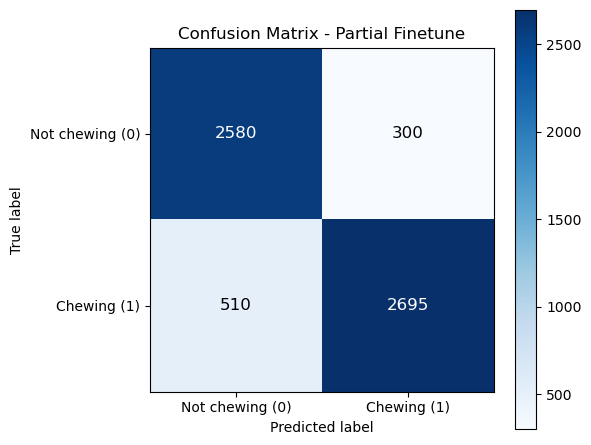

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_new, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_title("Confusion Matrix - Partial Finetune")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

classes = ["Not chewing (0)", "Chewing (1)"]
ax.set_xticks(np.arange(2))
ax.set_yticks(np.arange(2))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)


for i in range(2):
    for j in range(2):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=12
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()